In [1]:
#import libraries

import pandas as pd
import matplotlib.pyplot as plt 
import matplotlib.colors as mcolors
from mpl_toolkits import mplot3d


In [5]:
cancer =pd.read_csv('./notebooks/dataset/wdbc.csv')
cancer

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [ ]:
#a quick summary of data 
cancer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [ ]:
cancer['diagnosis'].unique()
#give us a list of values within the column. this is useful for categorical values


array(['M', 'B'], dtype=object)

In [ ]:
#clean up value - we are also saving this change in the dictionary
cancer['diagnosis'] = cancer['diagnosis'].replace(
    {
        "M": "Malignant",
        "B": "Benign"


    }
)

In [10]:
cancer['diagnosis'].unique()

array(['Malignant', 'Benign'], dtype=object)

In [ ]:
#see the distribution of unique values, we use the normalize to
# see whether the data is balanced or not - this gives you % instead of count

cancer['diagnosis'].value_counts(normalize = True)

diagnosis
Benign       0.627417
Malignant    0.372583
Name: proportion, dtype: float64

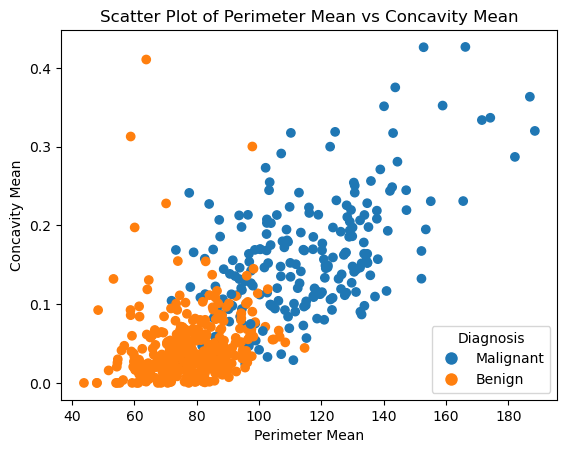

In [13]:
#visualization - we use this library to create the plots to analyze any patterns

labels = cancer["diagnosis"].unique().tolist()
colors = list(mcolors.TABLEAU_COLORS.keys())
color_map = {l: colors[i % len(colors)] for i, l in enumerate(labels)}

# Plot
plt.scatter(cancer["perimeter_mean"], cancer['concavity_mean'], 
            color=cancer["diagnosis"].map(color_map))

# Create custom legend handles
handles = [plt.Line2D([0], [0], marker='o', color='w', label=label,
                      markersize=10, markerfacecolor=color_map[label])
           for label in labels]

# Add labels and legend
plt.xlabel('Perimeter Mean')
plt.ylabel('Concavity Mean')
plt.title('Scatter Plot of Perimeter Mean vs Concavity Mean')
plt.legend(handles=handles, title='Diagnosis')
plt.show()



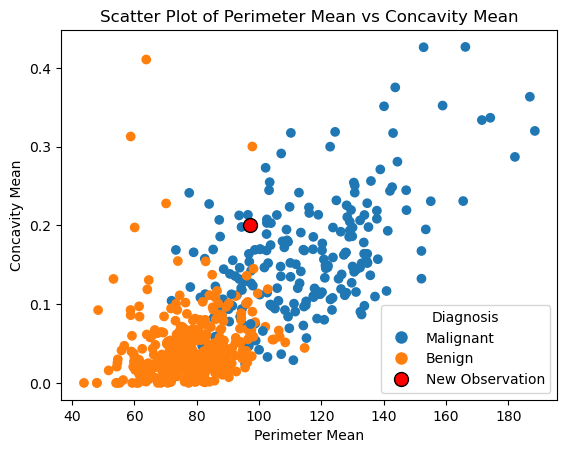

In [14]:
# Plot existing data
plt.scatter(cancer["perimeter_mean"], cancer['concavity_mean'], 
            color=cancer["diagnosis"].map(color_map))

# Create custom legend handles
handles = [plt.Line2D([0], [0], marker='o', color='w', label=label,
                      markersize=10, markerfacecolor=color_map[label])
           for label in labels]

# Add new observation
new_observation = {'perimeter_mean': 97, 'concavity_mean': 0.20}
plt.scatter(new_observation['perimeter_mean'], new_observation['concavity_mean'],
            color='red', edgecolor='black', s=100, label='New Observation')

# Add labels and legend
plt.xlabel('Perimeter Mean')
plt.ylabel('Concavity Mean')
plt.title('Scatter Plot of Perimeter Mean vs Concavity Mean')
plt.legend(handles=handles + [plt.Line2D([0], [0], marker='o', color='w', 
                                          markerfacecolor='red', markeredgecolor='black', 
                                          markersize=10, label='New Observation')], 
           title='Diagnosis')
plt.show()

In [23]:
#new observation, we are doing it mannually
new_obs_Perimeter=97
new_obs_Concavity = 0.2


In [25]:
#this code is intended to substract the mean and the new value to find the delta then remember the formula w
#calculate the distance and we save the distance value in a new column

cancer['dist_from_new'] = (
(cancer['perimeter_mean'] - new_obs_Perimeter)**2+
(cancer['concavity_mean'] - new_obs_Concavity)**2
)**(1/2)




In [26]:
#k =5 from the cancer data set, find the 5 smallest distance datas, remember to use [[]] this is the 
#right sytanx in panda

nearest_5 = cancer.nsmallest(5,"dist_from_new") [[

    "perimeter_mean",
    "concavity_mean",
    "diagnosis",
    "dist_from_new"
]]

In [27]:
nearest_5

,perimeter_mean,concavity_mean,diagnosis,dist_from_new
291,97.03,0.05940,Benign,0.143765
138,96.85,0.15390,Malignant,0.156924
15,96.73,0.16390,Malignant,0.272403
514,97.26,0.07486,Malignant,0.288548
54,97.26,0.05253,Malignant,0.298910


In [ ]:
#add another example by introducing one more variable

new_obs_Perimeter =97
new_obs_Concavity=0.2
new_obs_Symmetry = 0.22


In [32]:
cancer['dist_from_new'] = (

(cancer['perimeter_mean' ] - new_obs_Perimeter)**2 +
(cancer['concavity_mean' ] - new_obs_Concavity)**2 +
(cancer['symmetry_mean' ] - new_obs_Symmetry)**2

)**(1/2)

In [34]:
nearest_5 = cancer.nsmallest(5,"dist_from_new") [[

    "perimeter_mean",
    "concavity_mean",
    "symmetry_mean",
    "diagnosis",
    "dist_from_new"
]]

In [35]:
nearest_5

,perimeter_mean,concavity_mean,symmetry_mean,diagnosis,dist_from_new
291,97.03,0.05940,0.1879,Benign,0.147305
138,96.85,0.15390,0.1957,Malignant,0.158795
15,96.73,0.16390,0.2303,Malignant,0.272597
514,97.26,0.07486,0.1561,Malignant,0.295539
54,97.26,0.05253,0.1616,Malignant,0.304562


In [37]:

#telling we want to transfer arrays to pandas dataframe because sklean works well with pandas
from sklearn import set_config
set_config(transform_output = "pandas")

In [38]:
from sklearn.neighbors import KNeighborsClassifier

In [39]:
cancer_train = cancer[["diagnosis","perimeter_mean","symmetry_mean","concavity_mean"]]
cancer_train

,diagnosis,perimeter_mean,symmetry_mean,concavity_mean
0,Malignant,122.80,0.2419,0.30010
1,Malignant,132.90,0.1812,0.08690
2,Malignant,130.00,0.2069,0.19740
3,Malignant,77.58,0.2597,0.24140
4,Malignant,135.10,0.1809,0.19800
...,...,...,...,...
564,Malignant,142.00,0.1726,0.24390
565,Malignant,131.20,0.1752,0.14400
566,Malignant,108.30,0.1590,0.09251
567,Malignant,140.10,0.2397,0.35140


In [40]:
knn = KNeighborsClassifier(n_neighbors = 5)
knn

KNeighborsClassifier()

In [41]:
# predictor - x, response - y
X = cancer_train[["perimeter_mean","concavity_mean", "symmetry_mean"]]
y = cancer_train["diagnosis"]

In [42]:
#fit knn model to data

knn.fit(X,y)

KNeighborsClassifier()

In [44]:


new_obs = pd.DataFrame({"perimeter_mean":[97],"concavity_mean":[0.20], "symmetry_mean":[0.22]})
new_obs

,perimeter_mean,concavity_mean,symmetry_mean
0,97,0.2,0.22


In [45]:
knn.predict(new_obs)

array(['Malignant'], dtype=object)